# Zillow Prize - EDA + Data Cleaning (Google Colab)

Notebook này dùng để:
- Đọc các file `train_2016_v2.csv`, `train_2017.csv`, `properties_2016.csv`, `properties_2017.csv`
- Ghép dữ liệu theo `parcelid`
- Thực hiện EDA: kích thước dữ liệu, kiểu dữ liệu, missing values, outliers, phân phối biến mục tiêu, tương quan
- Làm sạch dữ liệu: xử lý giá trị thiếu, tạo đặc trưng ngày, xử lý ngoại lai, mã hóa biến phân loại, scale dữ liệu
- Xuất file dữ liệu đã làm sạch

> Lưu ý: Biến mục tiêu của bộ Zillow là **`logerror`**, không phải trực tiếp là giá nhà.

In [ ]:
# Cách B: Mount Google Drive
# Bỏ comment 2 dòng dưới nếu file đang nằm trong Google Drive

# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

## 2) Khai báo đường dẫn file

- Nếu dùng upload trực tiếp: giữ nguyên như bên dưới.
- Nếu dùng Drive: sửa `BASE_PATH` thành thư mục chứa file.

In [ ]:
# Nếu file ở ngay thư mục làm việc của Colab, giữ nguyên '.'
BASE_PATH = "."

# Ví dụ nếu bạn lưu trong Drive:
# BASE_PATH = "/content/drive/MyDrive/zillow"

train_2016_path = os.path.join(BASE_PATH, "train_2016_v2.csv")
train_2017_path = os.path.join(BASE_PATH, "train_2017.csv")
properties_2016_path = os.path.join(BASE_PATH, "properties_2016.csv")
properties_2017_path = os.path.join(BASE_PATH, "properties_2017.csv")

In [ ]:
def load_csv_if_exists(path, low_memory=False):
    if os.path.exists(path):
        print(f"Đang đọc: {path}")
        return pd.read_csv(path, low_memory=low_memory)
    print(f"Không tìm thấy: {path}")
    return None

train_2016 = load_csv_if_exists(train_2016_path, low_memory=False)
train_2017 = load_csv_if_exists(train_2017_path, low_memory=False)
properties_2016 = load_csv_if_exists(properties_2016_path, low_memory=False)
properties_2017 = load_csv_if_exists(properties_2017_path, low_memory=False)

Đang đọc: ./train_2016_v2.csv
Đang đọc: ./train_2017.csv
Đang đọc: ./properties_2016.csv
Đang đọc: ./properties_2017.csv


## 3) Ghép dữ liệu theo năm

In [ ]:
merged_frames = []

if train_2016 is not None and properties_2016 is not None:
    df_2016 = train_2016.merge(properties_2016, how="left", on="parcelid")
    df_2016["data_year"] = 2016
    merged_frames.append(df_2016)
    print("2016 merged shape:", df_2016.shape)

if train_2017 is not None and properties_2017 is not None:
    df_2017 = train_2017.merge(properties_2017, how="left", on="parcelid")
    df_2017["data_year"] = 2017
    merged_frames.append(df_2017)
    print("2017 merged shape:", df_2017.shape)

if len(merged_frames) == 0:
    raise ValueError("Chưa có cặp file train + properties tương ứng để merge.")

df = pd.concat(merged_frames, axis=0, ignore_index=True)
print("Final merged shape:", df.shape)
df.head()

2016 merged shape: (90275, 61)
2017 merged shape: (77613, 61)
Final merged shape: (167888, 61)


,parcelid,logerror,transactiondate,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,data_year
0,11016594,0.0276,2016-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016
1,14366692,-0.1684,2016-01-01,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,2263.0,2263.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,468.0,NaN,NaN,33668120.0,-117677556.0,3643.0,NaN,NaN,NaN,NaN,NaN,1,261.0,NaN,6.059052e+07,32380.0,1286.0,NaN,96962.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,2014.0,NaN,NaN,346458.0,585529.0,2015.0,239071.0,10153.02,NaN,NaN,NaN,2016
2,12098116,-0.0040,2016-01-01,1.0,NaN,NaN,3.0,2.0,NaN,4.0,3.0,NaN,NaN,2217.0,2217.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34136312.0,-118175032.0,11423.0,NaN,NaN,NaN,NaN,NaN,0100,261.0,PSR6,6.037464e+07,47019.0,3101.0,275411.0,96293.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1940.0,NaN,NaN,61994.0,119906.0,2015.0,57912.0,11484.48,NaN,NaN,6.037464e+13,2016
3,12643413,0.0218,2016-01-02,1.0,NaN,NaN,2.0,2.0,NaN,4.0,2.0,NaN,NaN,839.0,839.0,NaN,NaN,NaN,NaN,6037.0,NaN,2.0,NaN,NaN,NaN,2.0,33755800.0,-118309000.0,70859.0,NaN,NaN,NaN,NaN,NaN,010C,266.0,LAR3,6.037296e+07,12447.0,3101.0,54300.0,96222.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1987.0,NaN,NaN,171518.0,244880.0,2015.0,73362.0,3048.74,NaN,NaN,6.037296e+13,2016
4,14432541,-0.0050,2016-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016


## 4) EDA cơ bản

In [ ]:
print("Kích thước dữ liệu:", df.shape)
print("\nSố cột:", len(df.columns))
print("\n5 dòng đầu:")
display(df.head())

print("\nThông tin kiểu dữ liệu:")
display(df.dtypes.value_counts())

print("\nTỷ lệ trùng lặp toàn bộ dòng:", round(df.duplicated().mean() * 100, 4), "%")

Kích thước dữ liệu: (167888, 61)

Số cột: 61

5 dòng đầu:


,parcelid,logerror,transactiondate,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,data_year
0,11016594,0.0276,2016-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016
1,14366692,-0.1684,2016-01-01,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,2263.0,2263.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,468.0,NaN,NaN,33668120.0,-117677556.0,3643.0,NaN,NaN,NaN,NaN,NaN,1,261.0,NaN,6.059052e+07,32380.0,1286.0,NaN,96962.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,2014.0,NaN,NaN,346458.0,585529.0,2015.0,239071.0,10153.02,NaN,NaN,NaN,2016
2,12098116,-0.0040,2016-01-01,1.0,NaN,NaN,3.0,2.0,NaN,4.0,3.0,NaN,NaN,2217.0,2217.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34136312.0,-118175032.0,11423.0,NaN,NaN,NaN,NaN,NaN,0100,261.0,PSR6,6.037464e+07,47019.0,3101.0,275411.0,96293.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1940.0,NaN,NaN,61994.0,119906.0,2015.0,57912.0,11484.48,NaN,NaN,6.037464e+13,2016
3,12643413,0.0218,2016-01-02,1.0,NaN,NaN,2.0,2.0,NaN,4.0,2.0,NaN,NaN,839.0,839.0,NaN,NaN,NaN,NaN,6037.0,NaN,2.0,NaN,NaN,NaN,2.0,33755800.0,-118309000.0,70859.0,NaN,NaN,NaN,NaN,NaN,010C,266.0,LAR3,6.037296e+07,12447.0,3101.0,54300.0,96222.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1987.0,NaN,NaN,171518.0,244880.0,2015.0,73362.0,3048.74,NaN,NaN,6.037296e+13,2016
4,14432541,-0.0050,2016-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016



Thông tin kiểu dữ liệu:


,count
float64,53
object,6
int64,2



Tỷ lệ trùng lặp toàn bộ dòng: 0.0 %


In [ ]:
# Kiểm tra biến mục tiêu
target_col = "logerror"
assert target_col in df.columns, "Không tìm thấy cột logerror."

print(df[target_col].describe())

count    167888.000000
mean          0.013906
std           0.165706
min          -4.655420
25%          -0.025300
50%           0.006000
75%           0.039200
max           5.262999
Name: logerror, dtype: float64


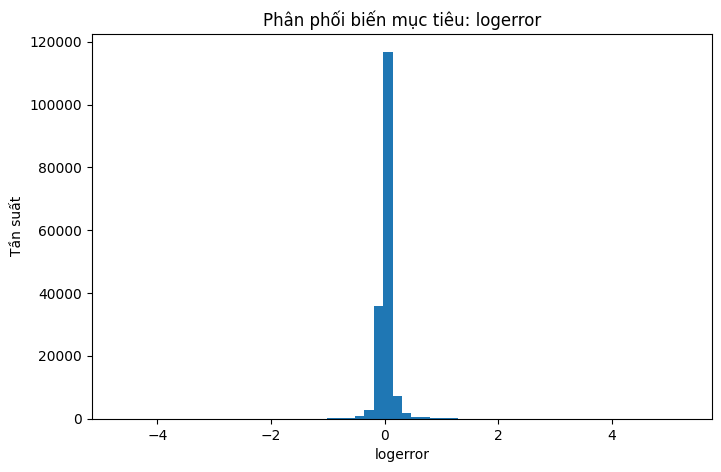

In [ ]:
# Phân phối logerror
plt.figure(figsize=(8, 5))
plt.hist(df[target_col].dropna(), bins=60)
plt.title("Phân phối biến mục tiêu: logerror")
plt.xlabel("logerror")
plt.ylabel("Tần suất")
plt.show()

In [ ]:
# Missing values
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100)

missing_summary = (
    pd.DataFrame({
        "column": df.columns,
        "missing_count": missing_count.values,
        "missing_pct": missing_pct.values,
        "dtype": df.dtypes.astype(str).values,
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
    })
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)

display(missing_summary.head(30))

,column,missing_count,missing_pct,dtype,n_unique
0,buildingclasstypeid,167857,99.981535,float64,2
1,finishedsquarefeet13,167814,99.955923,float64,17
2,basementsqft,167799,99.946988,float64,75
3,storytypeid,167799,99.946988,float64,1
4,yardbuildingsqft26,167726,99.903507,float64,111
5,fireplaceflag,167500,99.768894,object,1
6,architecturalstyletypeid,167430,99.727199,float64,6
7,typeconstructiontypeid,167377,99.695630,float64,4
8,finishedsquarefeet6,167097,99.528853,float64,639
9,decktypeid,166630,99.250691,float64,1


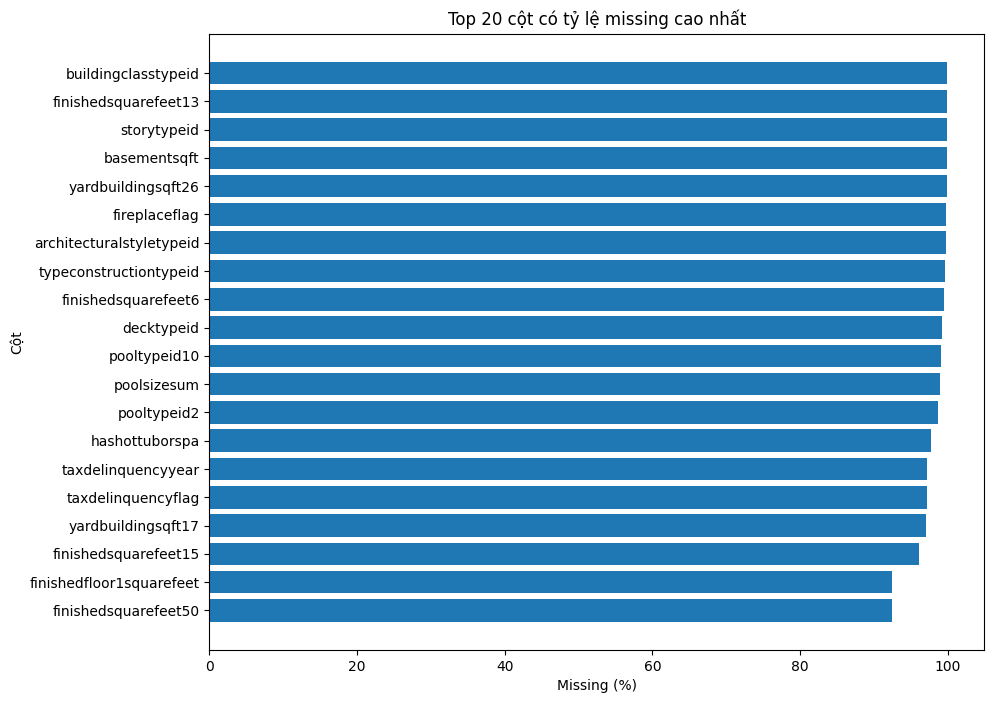

In [ ]:
# Vẽ top 20 cột thiếu nhiều nhất
top_missing = missing_summary.head(20).sort_values("missing_pct", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_missing["column"], top_missing["missing_pct"])
plt.title("Top 20 cột có tỷ lệ missing cao nhất")
plt.xlabel("Missing (%)")
plt.ylabel("Cột")
plt.show()

In [ ]:
# Thống kê biến số
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Số cột số:", len(numeric_cols))
print("Số cột phân loại/text:", len(categorical_cols))

display(df[numeric_cols].describe().T.head(20))

Số cột số: 55
Số cột phân loại/text: 6


,count,mean,std,min,25%,50%,75%,max
parcelid,167888.0,1.299536e+07,3.016071e+06,1.071174e+07,1.154899e+07,1.254060e+07,1.421930e+07,1.676893e+08
logerror,167888.0,1.390631e-02,1.657059e-01,-4.655420e+00,-2.530000e-02,6.000000e-03,3.920000e-02,5.262999e+00
airconditioningtypeid,52992.0,1.812915e+00,2.967880e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.300000e+01
architecturalstyletypeid,458.0,7.305677e+00,2.748863e+00,2.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,2.100000e+01
basementsqft,89.0,6.820674e+02,5.875450e+02,3.800000e+01,2.730000e+02,5.850000e+02,8.140000e+02,3.560000e+03
bathroomcnt,165312.0,2.288279e+00,1.000846e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,2.000000e+01
bedroomcnt,165312.0,3.041552e+00,1.149247e+00,0.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,1.600000e+01
buildingclasstypeid,31.0,3.967742e+00,1.796053e-01,3.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
buildingqualitytypeid,105593.0,6.021933e+00,1.881291e+00,1.000000e+00,4.000000e+00,7.000000e+00,7.000000e+00,1.200000e+01
calculatedbathnbr,163539.0,2.312580e+00,9.777944e-01,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,2.000000e+01


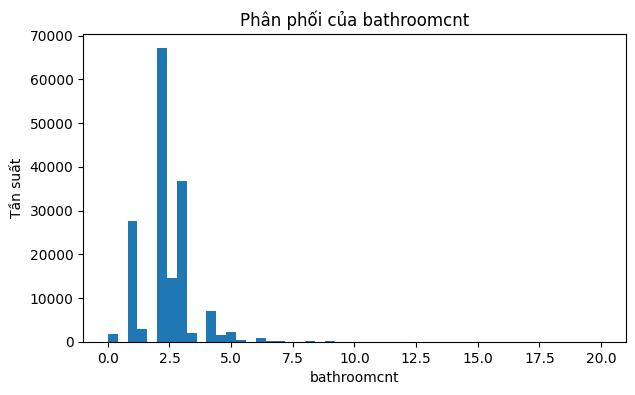

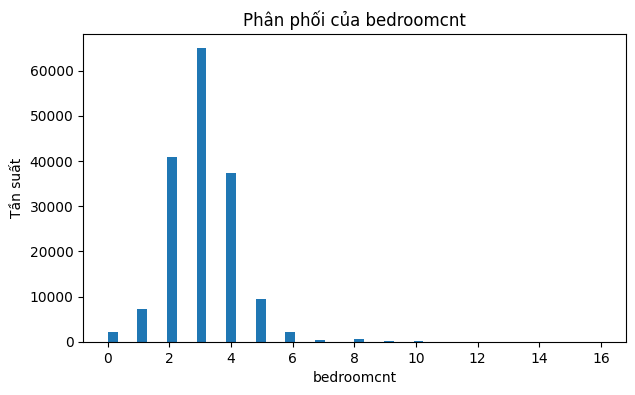

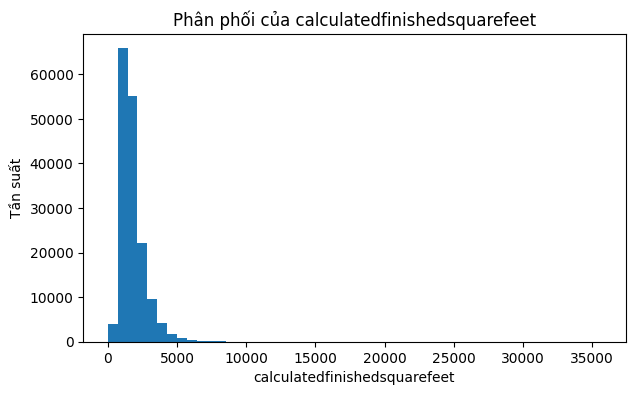

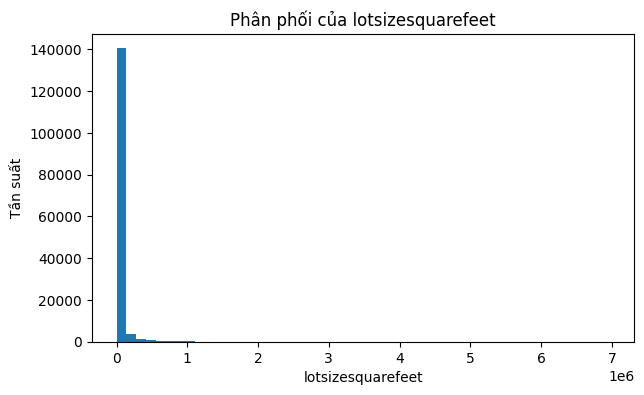

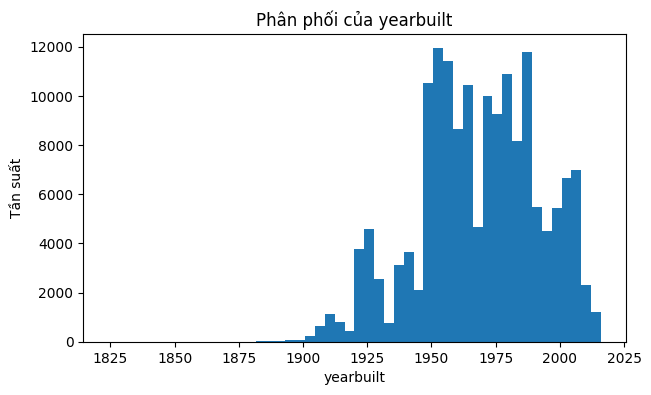

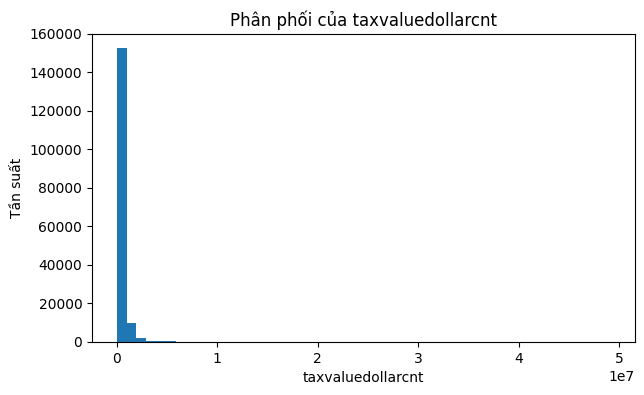

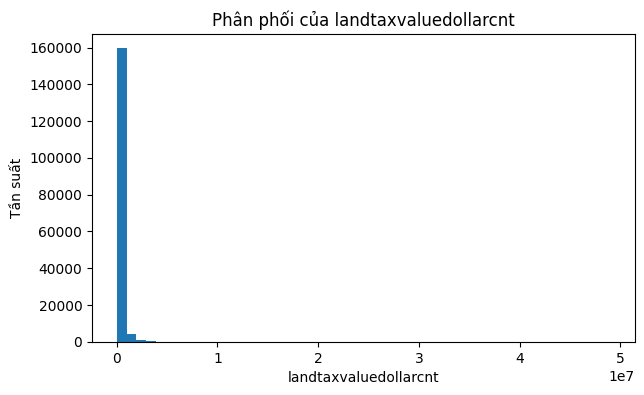

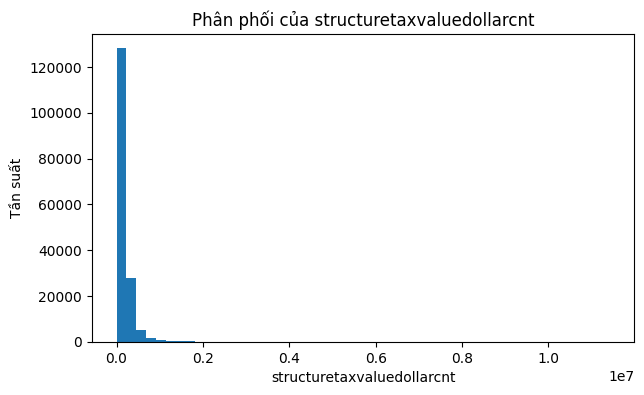

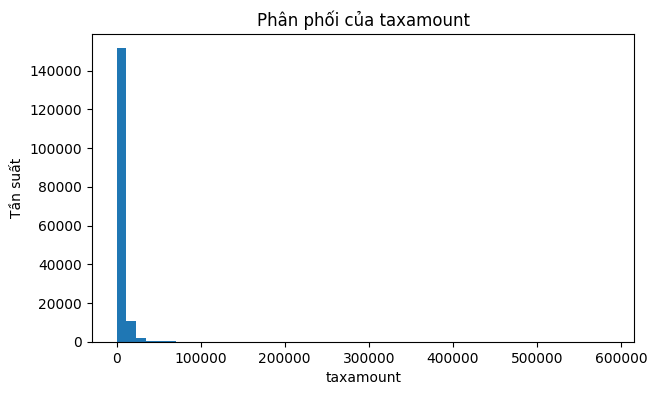

In [ ]:
# Xem phân phối của một số biến số quan trọng nếu tồn tại
candidate_cols = [
    "bathroomcnt",
    "bedroomcnt",
    "calculatedfinishedsquarefeet",
    "lotsizesquarefeet",
    "yearbuilt",
    "taxvaluedollarcnt",
    "landtaxvaluedollarcnt",
    "structuretaxvaluedollarcnt",
    "taxamount"
]

available_candidates = [c for c in candidate_cols if c in df.columns]

for col in available_candidates:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Phân phối của {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.show()

In [ ]:
# Tương quan với biến mục tiêu logerror
corr_target = (
    df[numeric_cols]
    .corr(numeric_only=True)[target_col]
    .dropna()
    .sort_values(ascending=False)
)

print("Top tương quan dương với logerror:")
display(corr_target.head(15))

print("Top tương quan âm với logerror:")
display(corr_target.tail(15))

Top tương quan dương với logerror:


,logerror
logerror,1.000000
basementsqft,0.324895
buildingclasstypeid,0.125978
yardbuildingsqft26,0.056297
finishedsquarefeet6,0.049060
finishedsquarefeet12,0.044157
calculatedfinishedsquarefeet,0.039824
garagetotalsqft,0.029621
calculatedbathnbr,0.029357
bedroomcnt,0.028745


Top tương quan âm với logerror:


,logerror
landtaxvaluedollarcnt,-0.001297
propertylandusetypeid,-0.002033
taxamount,-0.002634
latitude,-0.002980
regionidzip,-0.003990
regionidneighborhood,-0.005289
architecturalstyletypeid,-0.006427
regionidcounty,-0.007762
buildingqualitytypeid,-0.007947
finishedsquarefeet15,-0.008409


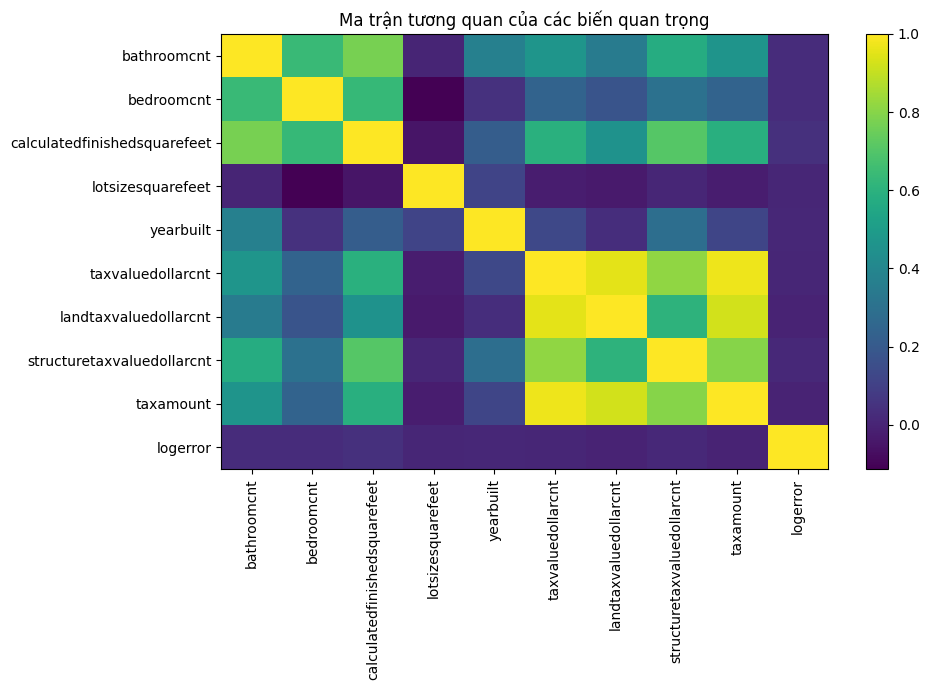

In [ ]:
# Ma trận tương quan cho một số biến quan trọng
corr_cols = [c for c in available_candidates if c in df.columns] + [target_col]
corr_cols = list(dict.fromkeys([c for c in corr_cols if c in df.columns]))

if len(corr_cols) >= 2:
    corr_matrix = df[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 7))
    im = plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar(im)
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.title("Ma trận tương quan của các biến quan trọng")
    plt.tight_layout()
    plt.show()

In [ ]:
# Hàm đếm outlier theo IQR
def count_outliers_iqr(series):
    s = series.dropna()
    if len(s) == 0:
        return 0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())

outlier_rows = []
for col in numeric_cols:
    if col == target_col:
        continue
    try:
        outlier_rows.append({
            "column": col,
            "outlier_count": count_outliers_iqr(df[col]),
            "non_null_count": int(df[col].notna().sum())
        })
    except Exception:
        pass

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary["outlier_pct_among_non_null"] = (
    outlier_summary["outlier_count"] / outlier_summary["non_null_count"] * 100
)
outlier_summary = outlier_summary.sort_values(
    "outlier_pct_among_non_null", ascending=False
).reset_index(drop=True)

display(outlier_summary.head(20))

,column,outlier_count,non_null_count,outlier_pct_among_non_null
0,garagecarcnt,14633,54575,26.812643
1,roomcnt,37582,165312,22.733982
2,taxdelinquencyyear,761,4626,16.450497
3,lotsizesquarefeet,24079,147162,16.362240
4,architecturalstyletypeid,74,458,16.157205
5,fireplacecnt,2681,17643,15.195828
6,yardbuildingsqft26,15,162,9.259259
7,finishedsquarefeet13,6,74,8.108108
8,fips,13272,165312,8.028455
9,rawcensustractandblock,13272,165312,8.028455


## 5) Data Cleaning

Chiến lược làm sạch trong notebook này:
- Xóa dòng trùng lặp
- Chuyển `transactiondate` sang kiểu datetime và tạo thêm `transaction_year`, `transaction_month`, `transaction_quarter`
- Xóa cột có tỷ lệ missing quá cao
- Xóa cột chỉ có 1 giá trị duy nhất
- Xử lý ngoại lai bằng cách cắt ngưỡng theo quantile 1% và 99% cho các biến số
- Điền missing:
  - số: median
  - phân loại: mode
- Mã hóa biến phân loại:
  - cột có cardinality thấp: One-Hot Encoding
  - cột có cardinality cao: Frequency Encoding
- Scale biến số bằng `StandardScaler`

In [ ]:
df_clean = df.copy()

# 1. Xóa trùng lặp
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Đã xóa {before - after} dòng trùng lặp.")

Đã xóa 0 dòng trùng lặp.


In [ ]:
# 2. Xử lý ngày giao dịch
if "transactiondate" in df_clean.columns:
    df_clean["transactiondate"] = pd.to_datetime(df_clean["transactiondate"], errors="coerce")
    df_clean["transaction_year"] = df_clean["transactiondate"].dt.year
    df_clean["transaction_month"] = df_clean["transactiondate"].dt.month
    df_clean["transaction_quarter"] = df_clean["transactiondate"].dt.quarter

In [ ]:
# 3. Xóa cột missing quá cao
MISSING_THRESHOLD = 0.98  # có thể đổi thành 0.95 nếu muốn mạnh tay hơn

missing_ratio = df_clean.isna().mean()
cols_drop_missing = missing_ratio[missing_ratio > MISSING_THRESHOLD].index.tolist()

print("Số cột bị xóa do thiếu quá nhiều:", len(cols_drop_missing))
print(cols_drop_missing[:30])

df_clean = df_clean.drop(columns=cols_drop_missing)
print("Shape sau khi xóa cột missing quá cao:", df_clean.shape)

Số cột bị xóa do thiếu quá nhiều: 13
['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedsquarefeet13', 'finishedsquarefeet6', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'storytypeid', 'typeconstructiontypeid', 'yardbuildingsqft26', 'fireplaceflag']
Shape sau khi xóa cột missing quá cao: (167888, 51)


In [ ]:
# 4. Xóa cột chỉ có 1 giá trị duy nhất
nunique = df_clean.nunique(dropna=False)
single_value_cols = nunique[nunique <= 1].index.tolist()

print("Số cột bị xóa vì chỉ có 1 giá trị:", len(single_value_cols))
print(single_value_cols[:30])

df_clean = df_clean.drop(columns=single_value_cols)
print("Shape sau khi xóa cột 1 giá trị:", df_clean.shape)

Số cột bị xóa vì chỉ có 1 giá trị: 0
[]
Shape sau khi xóa cột 1 giá trị: (167888, 51)


In [ ]:
# 5. Tách target và dữ liệu đầu vào
target = "logerror"
id_cols = [c for c in ["parcelid"] if c in df_clean.columns]

y = df_clean[target].copy()
X = df_clean.drop(columns=[target], errors="ignore")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (167888, 50)
y shape: (167888,)


In [ ]:
# 6. Xác định kiểu cột
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

# Bỏ transactiondate gốc khỏi categorical nếu có, vì đã tách thành year/month/quarter
if "transactiondate" in categorical_features:
    categorical_features.remove("transactiondate")
    X = X.drop(columns=["transactiondate"])

# Cập nhật lại danh sách cột
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 45
Categorical features: 4


In [ ]:
# 7. Xử lý outlier cho biến số bằng winsorize theo quantile
# Không áp dụng cho các cột ID nếu có
numeric_to_clip = [c for c in numeric_features if c not in id_cols]

X_clipped = X.copy()

for col in numeric_to_clip:
    s = X_clipped[col]
    if s.notna().sum() == 0:
        continue
    lower = s.quantile(0.01)
    upper = s.quantile(0.99)
    X_clipped[col] = s.clip(lower=lower, upper=upper)

X = X_clipped

In [ ]:
# 8. Chia categorical thành low-cardinality và high-cardinality
low_cardinality_cols = []
high_cardinality_cols = []

for col in categorical_features:
    n_uni = X[col].nunique(dropna=True)
    if n_uni <= 20:
        low_cardinality_cols.append(col)
    else:
        high_cardinality_cols.append(col)

print("Low-cardinality categorical:", len(low_cardinality_cols))
print("High-cardinality categorical:", len(high_cardinality_cols))
print("Ví dụ high-cardinality:", high_cardinality_cols[:10])

Low-cardinality categorical: 2
High-cardinality categorical: 2
Ví dụ high-cardinality: ['propertycountylandusecode', 'propertyzoningdesc']


In [ ]:
# 9. Frequency encoding cho cột categorical có cardinality cao
X_fe = X.copy()

for col in high_cardinality_cols:
    freq_map = X_fe[col].value_counts(normalize=True, dropna=False)
    X_fe[col + "_freq"] = X_fe[col].map(freq_map)

# Sau khi frequency encode thì bỏ cột gốc high-cardinality
X_fe = X_fe.drop(columns=high_cardinality_cols)

In [ ]:
# 10. Cập nhật lại danh sách cột
numeric_features_final = X_fe.select_dtypes(include=["number"]).columns.tolist()
categorical_features_final = X_fe.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric final:", len(numeric_features_final))
print("Categorical final:", len(categorical_features_final))

Numeric final: 47
Categorical final: 2


In [ ]:
# 11. Pipeline tiền xử lý cuối cùng
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_final),
        ("cat", categorical_transformer, categorical_features_final)
    ],
    remainder="drop"
)

In [ ]:
# 12. Fit-transform dữ liệu
X_processed = preprocessor.fit_transform(X_fe)

# Lấy tên cột sau khi biến đổi
feature_names = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(X_processed, columns=feature_names, index=X_fe.index)
final_df = pd.concat([X_processed_df, y.reset_index(drop=True)], axis=1)

print("Shape dữ liệu sau tiền xử lý:", final_df.shape)
display(final_df.head())

Shape dữ liệu sau tiền xử lý: (167888, 50)


,num__parcelid,num__airconditioningtypeid,num__bathroomcnt,num__bedroomcnt,num__buildingqualitytypeid,num__calculatedbathnbr,num__finishedfloor1squarefeet,num__calculatedfinishedsquarefeet,num__finishedsquarefeet12,num__finishedsquarefeet15,num__finishedsquarefeet50,num__fips,num__fireplacecnt,num__fullbathcnt,num__garagecarcnt,num__garagetotalsqft,num__heatingorsystemtypeid,num__latitude,num__longitude,num__lotsizesquarefeet,num__poolcnt,num__pooltypeid7,num__propertylandusetypeid,num__rawcensustractandblock,num__regionidcity,num__regionidcounty,num__regionidneighborhood,num__regionidzip,num__roomcnt,num__threequarterbathnbr,num__unitcnt,num__yardbuildingsqft17,num__yearbuilt,num__numberofstories,num__structuretaxvaluedollarcnt,num__taxvaluedollarcnt,num__assessmentyear,num__landtaxvaluedollarcnt,num__taxamount,num__taxdelinquencyyear,num__censustractandblock,num__data_year,num__transaction_year,num__transaction_month,num__transaction_quarter,num__propertycountylandusecode_freq,num__propertyzoningdesc_freq,cat__hashottuborspa_True,cat__taxdelinquencyflag_Y,logerror
0,-0.656075,-0.150081,-0.289097,-0.023303,0.395085,-0.320768,-0.043733,-0.259385,-0.252119,-0.050119,-0.045824,-0.566016,-0.120472,-0.252428,0.193107,0.196451,-0.395665,0.056200,0.066250,-0.264215,0.0,0.0,-0.213647,-0.556253,-0.178025,0.702231,-0.252995,-0.365919,-0.520147,0.0,-0.185141,-0.042892,0.058509,-0.310453,-0.273580,-0.248420,-0.926844,-0.261374,-0.252510,0.019511,-0.554162,-0.927221,-0.927221,-1.697974,-1.327635,-1.210994,1.316974,1.0,1.0,0.0276
1,0.454677,-0.150081,1.302766,0.905111,0.395085,1.321163,-0.043733,0.595535,0.665416,-0.050119,-0.045824,0.501452,-0.120472,0.875742,0.193107,0.425241,-0.395665,-1.294501,1.469926,-0.321664,0.0,0.0,-0.213647,0.492546,-0.022488,-1.565704,-0.252995,1.033940,-0.520147,0.0,-0.185141,-0.042892,1.856285,-0.310453,1.070175,0.318131,-0.926844,-0.120824,0.885199,0.019511,-0.554162,-0.927221,-0.927221,-1.697974,-1.327635,-1.088341,1.316974,1.0,1.0,-0.1684
2,-0.297488,-0.150081,0.772145,-0.951718,-1.527376,0.773852,-0.043733,0.541067,0.608610,-0.050119,-0.045824,-0.566016,-0.120472,0.875742,0.193107,0.196451,-0.395665,0.491883,0.072388,-0.196010,0.0,0.0,-0.213647,-0.563094,0.295425,0.702231,1.177141,-0.600450,-0.520147,0.0,-0.185141,-0.042892,-1.225618,-0.310453,-0.729597,-0.801896,-0.926844,-0.740528,1.153110,0.019511,-0.561022,-0.927221,-0.927221,-1.697974,-1.327635,1.303649,-0.813224,1.0,1.0,-0.0040
3,-0.116690,-0.150081,-0.289097,-0.951718,-1.527376,-0.320768,-0.043733,-1.090624,-1.093090,-0.050119,-0.045824,-0.566016,-0.120472,-0.252428,0.193107,0.196451,-0.395665,-0.959958,-0.303962,0.763927,0.0,0.0,1.037258,-0.571285,-0.455371,0.702231,-0.842923,-0.773905,-0.520147,0.0,-0.185141,-0.042892,0.786180,-0.310453,-0.036650,-0.501279,-0.926844,-0.687677,-0.544298,0.019511,-0.569235,-0.927221,-0.927221,-1.697974,-1.327635,-0.456466,-0.657025,1.0,1.0,0.0218
4,0.476510,-0.150081,-0.289097,-0.023303,0.395085,-0.320768,-0.043733,-0.259385,-0.252119,-0.050119,-0.045824,-0.566016,-0.120472,-0.252428,0.193107,0.196451,-0.395665,0.056200,0.066250,-0.264215,0.0,0.0,-0.213647,-0.556253,-0.178025,0.702231,-0.252995,-0.365919,-0.520147,0.0,-0.185141,-0.042892,0.058509,-0.310453,-0.273580,-0.248420,-0.926844,-0.261374,-0.252510,0.019511,-0.554162,-0.927221,-0.927221,-1.697974,-1.327635,-1.210994,1.316974,1.0,1.0,-0.0050


In [ ]:
# 13. Kiểm tra missing sau xử lý
print("Tổng số missing sau xử lý:", int(final_df.isna().sum().sum()))

Tổng số missing sau xử lý: 0


In [ ]:
# 14. Lưu dữ liệu
output_dir = os.path.join(BASE_PATH, "zillow_outputs")
os.makedirs(output_dir, exist_ok=True)

raw_merged_path = os.path.join(output_dir, "zillow_merged_raw.csv")
clean_basic_path = os.path.join(output_dir, "zillow_clean_basic.csv")
processed_path = os.path.join(output_dir, "zillow_processed_for_model.csv")
missing_report_path = os.path.join(output_dir, "missing_summary.csv")
outlier_report_path = os.path.join(output_dir, "outlier_summary.csv")

df.to_csv(raw_merged_path, index=False)
df_clean.to_csv(clean_basic_path, index=False)
final_df.to_csv(processed_path, index=False)
missing_summary.to_csv(missing_report_path, index=False)
outlier_summary.to_csv(outlier_report_path, index=False)

print("Đã lưu file tại:", output_dir)
print("-", raw_merged_path)
print("-", clean_basic_path)
print("-", processed_path)
print("-", missing_report_path)
print("-", outlier_report_path)

Đã lưu file tại: ./zillow_outputs
- ./zillow_outputs/zillow_merged_raw.csv
- ./zillow_outputs/zillow_clean_basic.csv
- ./zillow_outputs/zillow_processed_for_model.csv
- ./zillow_outputs/missing_summary.csv
- ./zillow_outputs/outlier_summary.csv
